In [47]:
import random
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector
from qiskit_ibm_runtime import SamplerV2 as Sampler

In [2]:
SEED = 1234
backend = AerSimulator(seed_simulator=SEED)
sampler = Sampler(backend)

# Superdense coding

Superdense coding is a quantum protocol that allows for the transmission of two classical bits using only one qubit of quantum communication, provided that Alice and Bob already share an entangled pair.

The protocol starts by preparing a Bell state and distributing one qubit to Alice and the other one to Bob. Alice then encodes two classical bits by applying a specific quantum gate to her qubit. After that, she sends her qubit to Bob, who combines both qubits and performs a measurement to recover the original two-bit message.

If Alice wants to send $00$, she does not apply any gate to her qubit. If she wants to send $01$, she applies an $X$ gate. If she wants to send $10$, she applies a $Z$ gate. Finally, if she wants to send $11$, she applies both $X$ and $Z$ gates.

Therefore, Alice encodes the two classical bits by modifying only her half of the entangled pair:

| Message | Alice's operation |
|---|---|
| $00$ | $I$ |
| $01$ | $X$ |
| $10$ | $Z$ |
| $11$ | $XZ$ |

After applying the corresponding operation, Alice sends her qubit to Bob. Bob now has both qubits, so he can apply the inverse Bell-state preparation circuit and measure them. The measurement result gives him the two classical bits that Alice wanted to transmit.

In [ ]:
def superdense_coding(bits: str) -> QuantumCircuit:
    """
    Create a quantum circuit for superdense coding based on the input bits.
    """
    # Validate input
    if bits not in {"00", "01", "10", "11"}:
        raise ValueError("Bits must be one of: '00', '01', '10', '11'")
    
    # Create quantum registers and circuit
    alice = QuantumRegister(1, "Alice")
    bob = QuantumRegister(1, "Bob")
    qc = QuantumCircuit(alice, bob)

    # Create the entangled pair (Bell state)
    qc.h(alice[0])
    qc.cx(alice[0], bob[0])
    qc.barrier()

    # Encode the bits into the quantum state
    if bits[0] == "1":
        qc.z(alice[0])
    if bits[1] == "1":
        qc.x(alice[0])
    qc.barrier()

    # Reverse the entanglement to decode the bits
    qc.cx(alice[0], bob[0])
    qc.h(alice[0])

    # Measure to retrieve the original bits
    qc.measure_all()

    return qc

Encoding bits 00
Measurement result: ['00']


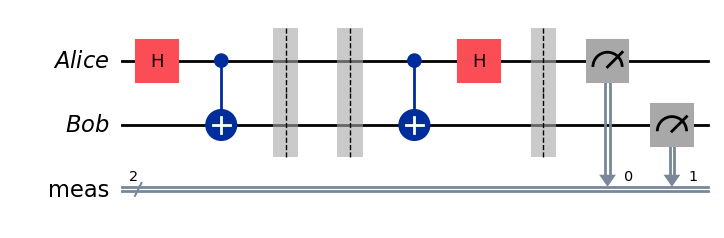

Encoding bits 01
Measurement result: ['10']


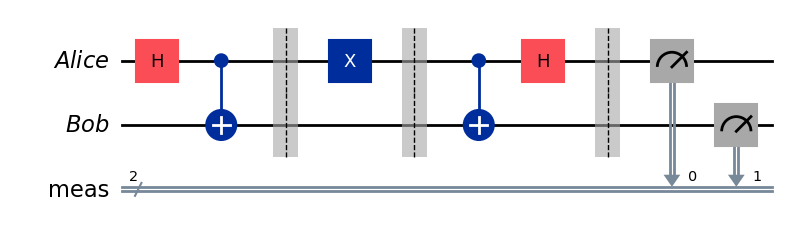

Encoding bits 10
Measurement result: ['01']


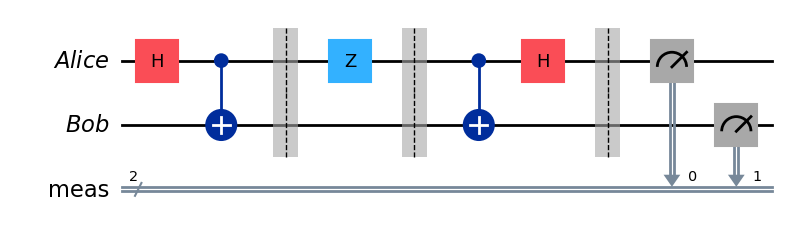

Encoding bits 11
Measurement result: ['11']


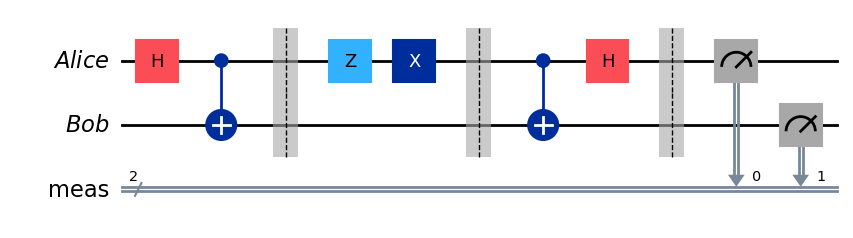

In [4]:
# Simulate all posible 2-bit combinations
bits_list = ["00", "01", "10", "11"]

for bits in bits_list:
    qc = superdense_coding(bits) # Build the circuit for the given bits
    job = sampler.run([qc], shots=1)
    measured_bits = job.result()[0].data.meas.get_bitstrings() # Get the measured bits
    print("Encoding bits", bits)
    print("Measurement result:", measured_bits[::-1]) # Reverse the bits to match the original order

    display(qc.draw("mpl"))

The results show that the superdense coding protocol correctly recovers the two classical bits encoded by Alice. For each possible input, Bob's measurement matches the original message, confirming that two classical bits can be transmitted using only one qubit and a shared entangled pair.

# CHSH game

The CHSH game is a two-player non-local game used to show the difference between classical and quantum correlations. Alice and Bob are separated and cannot communicate during the game. Each of them receives a random input bit: Alice receives $x$ and Bob receives $y$. Then, Alice outputs a bit $a$ and Bob outputs a bit $b$.

They win the game if their outputs satisfy:

$$
a \oplus b = x \land y
$$

This means that Alice and Bob should output different bits only when both inputs are equal to $1$. In all other cases, their outputs should be the same.

Classically, the best strategy can win at most $75\%$ of the time. For example, Alice and Bob can always output $0$. This wins for the input pairs $(0,0)$, $(0,1)$ and $(1,0)$, but fails for $(1,1)$. Therefore, this strategy wins in 3 out of the 4 possible cases.

In the quantum version of the CHSH game, Alice and Bob first share an entangled Bell state. During the game, they cannot communicate, but they can choose how to measure their qubits depending on the input bit they receive.

In this implementation, the measurement basis is changed by applying $R_y$ rotations before measuring in the computational basis.

| Player | Input bit | Operation applied before measurement |
|---|---:|---|
| Alice | $x = 0$ | Nothing |
| Alice | $x = 1$ | $R_y(\pi/2)$ |
| Bob | $y = 0$ | $R_y(\pi/4)$ |
| Bob | $y = 1$ | $R_y(-\pi/4)$ |

Alice's strategy is simple: if she receives input $0$, she measures directly; if she receives input $1$, she first rotates her qubit by $R_y(\pi/2)$ and then measures.

Bob also changes his measurement depending on his input. If he receives $0$, he applies $R_y(\pi/4)$; if he receives $1$, he applies $R_y(-\pi/4)$. These two angles are chosen so that Bob's measurements are halfway between Alice's two possible measurement bases.

The key idea is that Alice and Bob are not choosing their answers randomly. They are using the correlations of the shared entangled state together with carefully chosen measurement bases. This allows them to win the CHSH game with probability around:

$$
\cos^2\left(\frac{\pi}{8}\right) \approx 0.854
$$


In [66]:
def chsh_game(x: int, y: int) -> QuantumCircuit:
    """"
    Create a quantum circuit for the CHSH game based on the input bits a and b.
    """
    # Validate input
    if any(i not in (0, 1) for i in (x, y)):
        raise ValueError("a and b must be 0 or 1")

    # Create quantum registers and circuit
    alice = QuantumRegister(1, "Alice")
    bob = QuantumRegister(1, "Bob")
    qc = QuantumCircuit(alice, bob)

    # Create the entangled pair (Bell state)
    qc.h(alice[0])
    qc.cx(alice[0], bob[0])
    qc.barrier()

    # Apply the appropriate rotations based on the input bits
    if x:
        qc.ry(np.pi/2,alice[0])
    qc.barrier()

    if y:
        qc.ry(-np.pi/4, bob[0])
    else:
        qc.ry(np.pi/4, bob[0])

    # Measure to retrieve the outputs for Alice and Bob
    qc.measure_all()

    return qc

##############################
Circuit example:
##############################
Input bits: x = 1 , y = 0


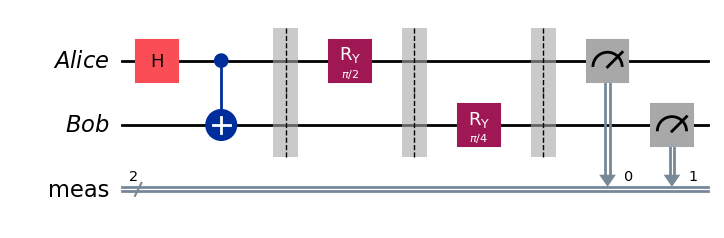

##############################
Winning probability: 85.40%
##############################


In [73]:
random.seed(SEED) # For reproducibility
print_one_circuit = True # For visualization

# Simulate the game and calculate the winning probability
n_trials = 1000
n_wins = 0

# Generate random inputs for Alice and Bob
x_list = random.choices([0, 1], k=n_trials)
y_list = random.choices([0, 1], k=n_trials)

# Build the circuits for all trials
qc_list = []
for x, y in zip(x_list, y_list):
    qc = chsh_game(x, y)
    qc_list.append(qc)
    if print_one_circuit: 
        print(30 * "#")
        print("Circuit example:")
        print(30 * "#")
        print("Input bits: x =", x, ", y =", y)
        display(qc.draw("mpl"))
        print_one_circuit = False

# Run all circuits in a single batch
job = sampler.run(qc_list, shots = 1)
results = job.result()

# Analyze the results to calculate the winning probability
for i in range(n_trials):
    bits = results[i].data.meas.get_bitstrings()[0]
    a = int(bits[0])
    b = int(bits[1])

    if x_list[i]*y_list[i] == 0:
        if a == b:
            n_wins+=1
    else:
        if a != b:
            n_wins+=1
            
print(30 * "#")
print(f"Winning probability: {100 * n_wins/n_trials:.2f}%")
print(30 * "#")

The simulation gives a winning probability of $85.40\%$, which matches the expected theoretical value for the quantum strategy. This confirms that the implementation behaves as expected and that the chosen rotations correctly reproduce the correlations used in the CHSH game.

# Quantum teleportation

Quantum teleportation is a protocol that allows the state of a qubit to be transferred from Alice to Bob without physically sending the qubit itself. This is useful because quantum information cannot be copied directly, but it can be reconstructed somewhere else using entanglement and classical communication.

Again, Alice and Bob share an entangled Bell pair. The protocol starts with Alice preparing the qubit state $|\psi\rangle$ that she wants to teleport. Alice then applies a CNOT gate controlled by its original $|\psi\rangle$ qubit and targeted to her qubit from the Bell pair, followed by a H gate on her original qubit. Alice then measures those two qubits, producing two classical bits that are sent to Bob. Depending on these classical bits, Bob applies correction gates to his qubit: if the bit associated with Alice's Bell-pair qubit is $1$, Bob applies an $X$ gate; if the bit associated with Alice's original qubit is $1$, Bob applies a $Z$ gate. After these corrections, Bob's qubit is left in the original state $|\psi\rangle$.

In [64]:
def quantum_teleportation(alice_state: QuantumCircuit) -> QuantumCircuit:
    """
    Implements the quantum teleportation protocol for a given 1-qubit state prepared by Alice.
    """
    # Validate input
    if alice_state.num_qubits != 1:
        raise ValueError("Alice's state must be a 1-qubit circuit.")
    
    # Create quantum registers and circuit
    psi = QuantumRegister(1, "psi")
    alice = QuantumRegister(1, "Alice")
    bob = QuantumRegister(1, "Bob")
    aux = ClassicalRegister(2, "aux")
    final = ClassicalRegister(1, "final")
    qc = QuantumCircuit(psi, alice, bob, aux, final)

    # Prepare Alice's initial state on psi
    qc.compose(alice_state, qubits=[psi[0]], inplace=True)
    qc.barrier()
    
    # Create the entangled pair (Bell state)
    qc.h(alice[0])
    qc.cx(alice[0], bob[0])
    qc.barrier()

    # Apply the teleportation protocol
    qc.cx(psi[0], alice[0])
    qc.h(psi[0])
    qc.barrier()

    # Perform the measurements to retrieve the classical bits
    qc.measure([psi[0], alice[0]], [aux[0], aux[1]])
    qc.barrier()

    # Apply the appropriate gates to Bob's qubit based on the measurement results
    with qc.if_test((aux[0], 1)):
        qc.z(bob[0])
    with qc.if_test((aux[1], 1)):
        qc.x(bob[0])
    qc.barrier()

    # Measure Bob's qubit to verify the teleportation
    qc.measure(bob[0], final[0])

    return qc

Teleportation result: {'1': 308, '0': 1740}
Original state result: {'0': 1763, '1': 285}


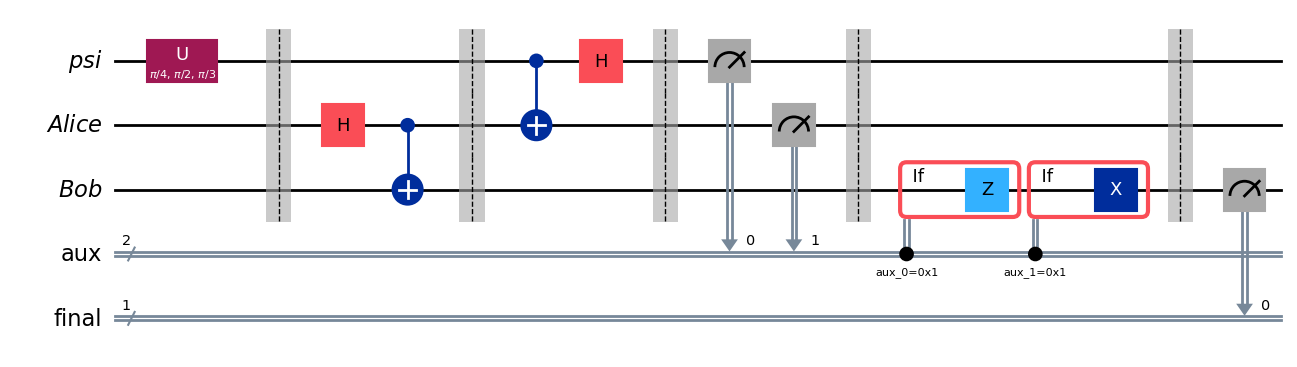

In [65]:
# Prepare a specific state for Alice
alice_state = QuantumCircuit(1) 
alice_state.u(np.pi/4, np.pi/2, np.pi/3, 0)

# Build the teleportation circuit
qc = quantum_teleportation(alice_state)

# Create a separate circuit to measure Alice's original state
alice_state_measured = alice_state.copy()
alice_state_measured.measure_all()

# Run both circuits
job = sampler.run([qc, alice_state_measured], shots=2048)
result = job.result()

# Get results separately
teleportation_results = result[0].data.final.get_counts()
original_state_results = result[1].data.meas.get_counts()

print("Teleportation result:", teleportation_results)
print("Original state result:", original_state_results)

display(qc.draw("mpl"))

The teleported state produces a measurement distribution very close to the original state, with most shots resulting in $0$ and a smaller number in $1$. This confirms that the teleportation circuit correctly transfers Alice's quantum state to Bob's qubit.